# DPL Tag Classifier — CPU-Friendly Training

This notebook trains **two models** optimised for CPU speed:

| Model | Speed | Expected F1 | Best for |
|---|---|---|---|
| **TF-IDF + LinearSVC** | < 10 seconds | ~0.90–0.96 | Fastest baseline |
| **DistilBERT fine-tuned** | ~5–15 min on CPU | ~0.93–0.97 | Better on ambiguous descriptions |

For short, structured financial text (DPL descriptions) TF-IDF + LinearSVC is often within 2–3% of DeBERTa while being **100× faster**.

## Structure
1. Load dataset  
2. Label encoding  
3. **Model A** — TF-IDF + LinearSVC (seconds)  
4. **Model B** — TF-IDF + Logistic Regression (seconds, gives probabilities)  
5. **Model C** — DistilBERT fine-tuned (minutes, best accuracy)  
6. Compare all models  
7. Save best model  
8. Inference helper  

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import json
import os
import time
import warnings
warnings.filterwarnings("ignore")

DATASETS_DIR = "datasets"

train_df = pd.read_csv(f"{DATASETS_DIR}/dpl_train.csv")
val_df   = pd.read_csv(f"{DATASETS_DIR}/dpl_val.csv")
test_df  = pd.read_csv(f"{DATASETS_DIR}/dpl_test.csv")

# Combine train+val for final model (no need for val split in sklearn)
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Train     : {len(train_df):,} rows")
print(f"Val       : {len(val_df):,} rows")
print(f"Test      : {len(test_df):,} rows")
print(f"Train+Val : {len(trainval_df):,} rows")
print(f"Tags      : {train_df['dpl_tag'].nunique()}")
train_df.head(5)

Train     : 10,584 rows
Val       : 2,267 rows
Test      : 2,272 rows
Train+Val : 12,851 rows
Tags      : 76


,description,dpl_tag
0,Audit planning fees – Deloitte – June,DPL003
1,Operational income adjustment – January 2023,DPL045
2,COVID-19 wage support grant – 2026,DPL071
3,Business process outsourcing charge – 2023,DPL049
4,Employee redundancy payments – Sep 2026,DPL059


## 2. Label Encoding

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
all_tags = sorted(train_df["dpl_tag"].unique().tolist())
le.fit(all_tags)
NUM_LABELS = len(le.classes_)

X_train    = train_df["description"].tolist()
y_train    = le.transform(train_df["dpl_tag"])
X_val      = val_df["description"].tolist()
y_val      = le.transform(val_df["dpl_tag"])
X_test     = test_df["description"].tolist()
y_test     = le.transform(test_df["dpl_tag"])
X_trainval = trainval_df["description"].tolist()
y_trainval = le.transform(trainval_df["dpl_tag"])

print(f"Classes: {NUM_LABELS}")
print(f"Sample: '{X_train[0]}' → {le.classes_[y_train[0]]}")

Classes: 76
Sample: 'Audit planning fees – Deloitte – June' → DPL003


## 3. Model A — TF-IDF + LinearSVC

Fastest option. Trains in under 10 seconds. Excellent for short, structured text.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

# TF-IDF with word unigrams + bigrams AND character n-grams for robustness
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),      # unigrams, bigrams, trigrams
    min_df=2,
    max_features=100_000,
    sublinear_tf=True,
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),      # character n-grams catch typos and abbreviations
    min_df=3,
    max_features=50_000,
    sublinear_tf=True,
)

from sklearn.pipeline import FeatureUnion

features = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf),
])

svc_pipeline = Pipeline([
    ("features", features),
    ("clf", LinearSVC(C=1.0, max_iter=2000, dual="auto")),
])

t0 = time.time()
svc_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

svc_preds = svc_pipeline.predict(X_test)

svc_acc = accuracy_score(y_test, svc_preds)
svc_f1  = f1_score(y_test, svc_preds, average="weighted", zero_division=0)

print(f"Training time : {train_time:.1f}s")
print(f"Accuracy      : {svc_acc:.4f}")
print(f"Weighted F1   : {svc_f1:.4f}")

Training time : 5.5s
Accuracy      : 0.9982
Weighted F1   : 0.9982


In [8]:
# Full classification report
pred_tags = le.inverse_transform(svc_preds)
true_tags = le.inverse_transform(y_test)
print(classification_report(true_tags, pred_tags, zero_division=0))

              precision    recall  f1-score   support

      DPL001       1.00      1.00      1.00        30
      DPL002       1.00      1.00      1.00        30
      DPL003       1.00      1.00      1.00        30
      DPL004       1.00      1.00      1.00        30
      DPL005       1.00      0.97      0.98        30
      DPL006       1.00      1.00      1.00        30
      DPL007       1.00      1.00      1.00        30
      DPL008       1.00      1.00      1.00        30
      DPL009       1.00      1.00      1.00        30
      DPL010       1.00      1.00      1.00        30
      DPL011       1.00      1.00      1.00        30
      DPL012       1.00      1.00      1.00        30
      DPL013       1.00      1.00      1.00        30
      DPL014       1.00      1.00      1.00        30
      DPL015       1.00      1.00      1.00        30
      DPL016       1.00      1.00      1.00        30
      DPL017       1.00      1.00      1.00        30
      DPL018       1.00    

## 4. Model B — TF-IDF + Logistic Regression

Slightly slower than SVC but gives calibrated **probability scores** per class — useful for confidence thresholds.

In [10]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1,3),
                                  min_df=2, max_features=100_000, sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5),
                                  min_df=3, max_features=50_000, sublinear_tf=True)),
    ])),
    ("clf", LogisticRegression(
        C=5.0, max_iter=1000, solver="saga", n_jobs=-1
    )),
])

t0 = time.time()
lr_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)  # top-k probabilities available

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average="weighted", zero_division=0)

print(f"Training time : {train_time:.1f}s")
print(f"Accuracy      : {lr_acc:.4f}")
print(f"Weighted F1   : {lr_f1:.4f}")

Training time : 59.4s
Accuracy      : 0.9982
Weighted F1   : 0.9982


In [11]:
# Top-3 confidence demo
sample_desc = "Interest charged on HSBC overdraft – January 2025"
sample_prob = lr_pipeline.predict_proba([sample_desc])[0]
top3_idx    = np.argsort(sample_prob)[::-1][:3]

print(f"Description: {sample_desc}\n")
print(f"{'Rank':<6} {'DPL Tag':<10} {'Confidence':>10}")
print("-" * 30)
for rank, idx in enumerate(top3_idx, 1):
    print(f"{rank:<6} {le.classes_[idx]:<10} {sample_prob[idx]:>10.4f}")

Description: Interest charged on HSBC overdraft – January 2025

Rank   DPL Tag    Confidence
------------------------------
1      DPL035         0.9706
2      DPL076         0.0043
3      DPL006         0.0019


## 5. Model C — DistilBERT Fine-tuned (CPU)

`distilbert-base-uncased` is 40% smaller and 60% faster than BERT, with only ~3% accuracy drop.
On CPU it trains in ~5–15 minutes for this dataset.

In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score as sklearn_f1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

DISTILBERT_CHECKPOINT = "distilbert-base-uncased"
MAX_LENGTH = 64    # DPL descriptions are short — 64 is enough, faster than 128

id2label = {int(i): str(c) for i, c in enumerate(le.classes_)}
label2id = {str(c): int(i) for i, c in enumerate(le.classes_)}

tokenizer_db = AutoTokenizer.from_pretrained(DISTILBERT_CHECKPOINT)
print("Tokenizer loaded.")

Device: cpu
Tokenizer loaded.


In [13]:
def df_to_hf(df):
    return Dataset.from_dict({
        "text":  df["description"].tolist(),
        "label": le.transform(df["dpl_tag"]).tolist(),
    })

raw_ds = DatasetDict({
    "train": df_to_hf(train_df),
    "val":   df_to_hf(val_df),
    "test":  df_to_hf(test_df),
})

def tokenize(batch):
    return tokenizer_db(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tok_ds = raw_ds.map(tokenize, batched=True, remove_columns=["text"])
tok_ds.set_format("torch")
print(tok_ds)

Map:   0%|          | 0/10584 [00:00<?, ? examples/s]

Map:   0%|          | 0/2267 [00:00<?, ? examples/s]

Map:   0%|          | 0/2272 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10584
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2267
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2272
    })
})


In [14]:
model_db = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)
model_db.to(DEVICE)

total = sum(p.numel() for p in model_db.parameters())
print(f"Parameters: {total:,}  (~{total/1e6:.0f}M)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 67,011,916  (~67M)


In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":   accuracy_score(labels, preds),
        "f1_weighted": sklearn_f1(labels, preds, average="weighted", zero_division=0),
    }

EPOCHS     = 5
BATCH_SIZE = 64   # larger batch = fewer steps = faster on CPU
n_train    = len(tok_ds["train"])
total_steps = max(1, n_train // BATCH_SIZE) * EPOCHS
warmup_steps = int(total_steps * 0.1)
print(f"Total steps: {total_steps}  |  Warmup: {warmup_steps}")

db_args = TrainingArguments(
    output_dir                  = "models/distilbert/checkpoints",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = 128,
    learning_rate               = 3e-5,         # slightly higher than DeBERTa — DistilBERT trains faster
    weight_decay                = 0.01,
    warmup_steps                = warmup_steps,
    lr_scheduler_type           = "cosine",
    bf16                        = torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16                        = torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    greater_is_better           = True,
    logging_steps               = 50,
    report_to                   = "none",
    save_total_limit            = 1,
    seed                        = 42,
    use_cpu                     = (DEVICE == "cpu"),   # explicit CPU flag
    dataloader_num_workers      = 0,    # set to 4 on Linux
)

db_trainer = Trainer(
    model            = model_db,
    args             = db_args,
    train_dataset    = tok_ds["train"],
    eval_dataset     = tok_ds["val"],
    processing_class = tokenizer_db,
    compute_metrics  = compute_metrics,
)
print("Trainer ready.")

Total steps: 825  |  Warmup: 82
Trainer ready.


In [17]:
t0 = time.time()
db_train_result = db_trainer.train()
db_train_time = time.time() - t0
print(f"\nDistilBERT training time: {db_train_time/60:.1f} min")
print(db_train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.932379,0.448519,0.982797,0.982592
2,0.156754,0.055585,0.999118,0.999125
3,0.051878,0.024539,1.000000,1.000000
4,0.032901,0.018729,1.000000,1.000000
5,0.030267,0.017981,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT training time: 88.1 min
TrainOutput(global_step=830, training_loss=0.3665704513170633, metrics={'train_runtime': 5286.1413, 'train_samples_per_second': 10.011, 'train_steps_per_second': 0.157, 'total_flos': 877428244869120.0, 'train_loss': 0.3665704513170633, 'epoch': 5.0})


In [18]:
# Evaluate DistilBERT on test set
db_output = db_trainer.predict(tok_ds["test"])
db_preds  = np.argmax(db_output.predictions, axis=-1)

db_acc = accuracy_score(y_test, db_preds)
db_f1  = sklearn_f1(y_test, db_preds, average="weighted", zero_division=0)
print(f"DistilBERT — Accuracy: {db_acc:.4f}  |  Weighted F1: {db_f1:.4f}")

DistilBERT — Accuracy: 1.0000  |  Weighted F1: 1.0000


## 6. Compare All Models

                    Accuracy  Weighted F1
Model                                    
TF-IDF + LinearSVC    0.9982       0.9982
TF-IDF + LogReg       0.9982       0.9982
DistilBERT            1.0000       1.0000


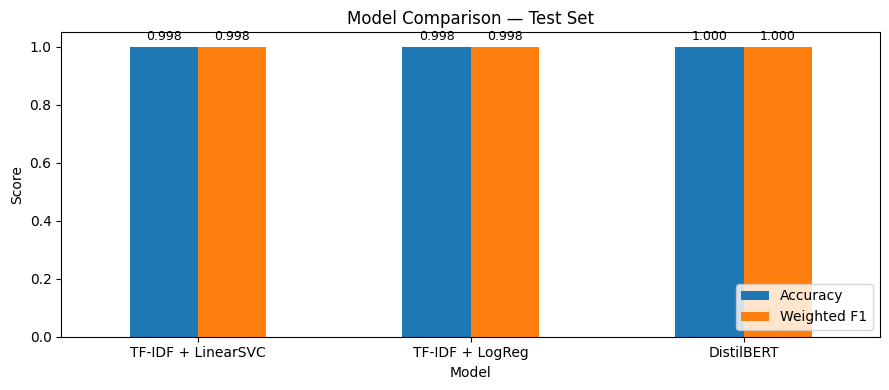

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

results = {
    "TF-IDF + LinearSVC":  {"accuracy": svc_acc, "f1_weighted": svc_f1,  "preds": svc_preds},
    "TF-IDF + LogReg":     {"accuracy": lr_acc,  "f1_weighted": lr_f1,   "preds": lr_preds},
    "DistilBERT":          {"accuracy": db_acc,  "f1_weighted": db_f1,   "preds": db_preds},
}

results_df = pd.DataFrame([
    {"Model": k, "Accuracy": v["accuracy"], "Weighted F1": v["f1_weighted"]}
    for k, v in results.items()
]).set_index("Model")

print(results_df.to_string(float_format="{:.4f}".format))

fig, ax = plt.subplots(figsize=(9, 4))
results_df.plot(kind="bar", ax=ax, width=0.5, rot=0)
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison — Test Set")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

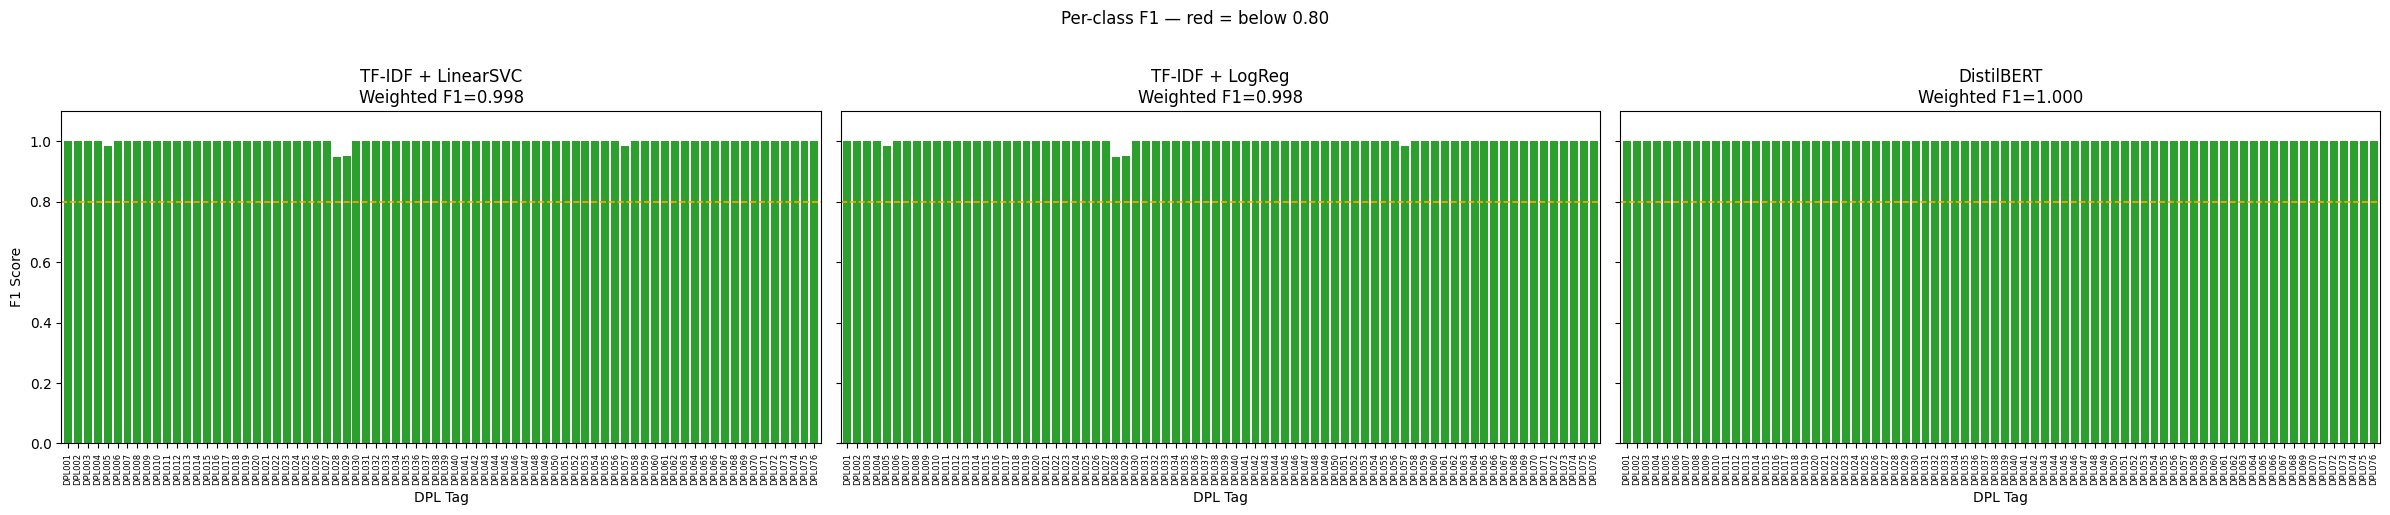

In [21]:
# Per-class F1 for all three models side-by-side
from sklearn.metrics import classification_report as cr_dict_fn

fig, axes = plt.subplots(1, 3, figsize=(24, 5), sharey=True)
tag_names = le.classes_.tolist()

for ax, (name, v) in zip(axes, results.items()):
    rep = cr_dict_fn(le.inverse_transform(y_test),
                     le.inverse_transform(v["preds"]),
                     output_dict=True, zero_division=0)
    f1s = pd.Series({t: rep[t]["f1-score"] for t in tag_names if t in rep}).sort_index()
    colors = ["#d62728" if v < 0.80 else "#2ca02c" for v in f1s.values]
    f1s.plot(kind="bar", ax=ax, color=colors, width=0.8)
    ax.axhline(0.80, color="orange", linestyle="--", linewidth=1.2)
    ax.set_title(f"{name}\nWeighted F1={v['f1_weighted']:.3f}")
    ax.set_xlabel("DPL Tag")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="x", labelsize=6, rotation=90)

axes[0].set_ylabel("F1 Score")
plt.suptitle("Per-class F1 — red = below 0.80", y=1.02)
plt.tight_layout()
plt.show()

## 7. Save Best Model

Both the sklearn pipeline and DistilBERT are saved.

In [22]:
import joblib

os.makedirs("models/tfidf_svc",   exist_ok=True)
os.makedirs("models/tfidf_lr",    exist_ok=True)
os.makedirs("models/distilbert/model", exist_ok=True)

# Re-fit sklearn models on train+val before saving (more data = better)
print("Re-fitting sklearn models on train+val...")
svc_pipeline.fit(X_trainval, y_trainval)
lr_pipeline.fit(X_trainval, y_trainval)

joblib.dump(svc_pipeline, "models/tfidf_svc/model.joblib")
joblib.dump(lr_pipeline,  "models/tfidf_lr/model.joblib")

label_map = {"id2label": id2label, "label2id": label2id}
for path in ["models/tfidf_svc", "models/tfidf_lr"]:
    with open(f"{path}/label_classes.json", "w") as f:
        json.dump(label_map, f, indent=2)

# Save DistilBERT
db_trainer.save_model("models/distilbert/model")
tokenizer_db.save_pretrained("models/distilbert/model")
with open("models/distilbert/label_classes.json", "w") as f:
    json.dump(label_map, f, indent=2)

# Save metrics summary
metrics_summary = {
    model_name: {"accuracy": float(v["accuracy"]), "f1_weighted": float(v["f1_weighted"])}
    for model_name, v in results.items()
}
with open("models/cpu_model_comparison.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("\nAll models saved:")
print("  models/tfidf_svc/model.joblib")
print("  models/tfidf_lr/model.joblib")
print("  models/distilbert/model/")
print("  models/cpu_model_comparison.json")

Re-fitting sklearn models on train+val...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


All models saved:
  models/tfidf_svc/model.joblib
  models/tfidf_lr/model.joblib
  models/distilbert/model/
  models/cpu_model_comparison.json


## 8. Inference Helper

Three inference styles — pick whichever model you want to deploy.

In [23]:
# ---- Inference with any saved sklearn model ----
def predict_sklearn(descriptions, model_path="models/tfidf_svc/model.joblib", top_k=3):
    """Predict DPL tag(s) for a list of descriptions using the sklearn pipeline."""
    pipe = joblib.load(model_path)
    with open(model_path.replace("model.joblib", "label_classes.json")) as f:
        lmap = json.load(f)

    preds = pipe.predict(descriptions)
    pred_tags = [lmap["id2label"][str(p)] for p in preds]

    # Probabilities only available for LR (not SVC without calibration)
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        probs = pipe.predict_proba(descriptions)
        top_tags = [
            [(lmap["id2label"][str(i)], float(probs[row][i]))
             for i in np.argsort(probs[row])[::-1][:top_k]]
            for row in range(len(descriptions))
        ]
    else:
        top_tags = [[(t, None)] for t in pred_tags]

    return pred_tags, top_tags


# ---- Test descriptions ----
test_descs = [
    "INV-55234 – Deloitte audit services FY2025",
    "Monthly payroll – March 2026 – Finance",
    "Interest charged on HSBC overdraft – January",
    "Google Ads campaign – Q2 2026",
    "Office rent – London HQ – April 2026",
    "Redundancy costs – IT department – 2025",
    "KPMG tax advisory fees",
    "AWS cloud hosting – February subscription",
    "Staff Christmas party expense – 2025",
    "FX loss on USD settlement – AP-78341",
]

print("=== TF-IDF + LinearSVC ===")
svc_pred_tags, _ = predict_sklearn(test_descs, "models/tfidf_svc/model.joblib")
for desc, tag in zip(test_descs, svc_pred_tags):
    print(f"  {desc:<55} → {tag}")

=== TF-IDF + LinearSVC ===
  INV-55234 – Deloitte audit services FY2025              → DPL003
  Monthly payroll – March 2026 – Finance                  → DPL068
  Interest charged on HSBC overdraft – January            → DPL035
  Google Ads campaign – Q2 2026                           → DPL001
  Office rent – London HQ – April 2026                    → DPL055
  Redundancy costs – IT department – 2025                 → DPL059
  KPMG tax advisory fees                                  → DPL003
  AWS cloud hosting – February subscription               → DPL037
  Staff Christmas party expense – 2025                    → DPL041
  FX loss on USD settlement – AP-78341                    → DPL043


In [24]:
print("=== TF-IDF + Logistic Regression (with confidence scores) ===")
lr_pred_tags, lr_top3 = predict_sklearn(test_descs, "models/tfidf_lr/model.joblib", top_k=3)

for desc, top in zip(test_descs, lr_top3):
    top_str = "  |  ".join(f"{tag} ({score:.3f})" for tag, score in top)
    print(f"  {desc:<55}")
    print(f"    {top_str}")

=== TF-IDF + Logistic Regression (with confidence scores) ===
  INV-55234 – Deloitte audit services FY2025             
    DPL003 (0.954)  |  DPL011 (0.002)  |  DPL008 (0.002)
  Monthly payroll – March 2026 – Finance                 
    DPL068 (0.947)  |  DPL057 (0.013)  |  DPL058 (0.005)
  Interest charged on HSBC overdraft – January           
    DPL035 (0.981)  |  DPL076 (0.003)  |  DPL006 (0.001)
  Google Ads campaign – Q2 2026                          
    DPL001 (0.977)  |  DPL053 (0.003)  |  DPL028 (0.001)
  Office rent – London HQ – April 2026                   
    DPL055 (0.963)  |  DPL059 (0.003)  |  DPL029 (0.002)
  Redundancy costs – IT department – 2025                
    DPL059 (0.967)  |  DPL037 (0.002)  |  DPL011 (0.002)
  KPMG tax advisory fees                                 
    DPL003 (0.928)  |  DPL038 (0.018)  |  DPL059 (0.011)
  AWS cloud hosting – February subscription              
    DPL037 (0.940)  |  DPL063 (0.016)  |  DPL066 (0.003)
  Staff Christmas 

In [25]:
from transformers import pipeline as hf_pipeline

print("=== DistilBERT ===")
db_classifier = hf_pipeline(
    "text-classification",
    model="models/distilbert/model",
    tokenizer="models/distilbert/model",
    device=-1,   # CPU
    top_k=3,
)

db_results = db_classifier(test_descs)
for desc, preds in zip(test_descs, db_results):
    top = preds[0]
    print(f"  {desc:<55} → {top['label']} ({top['score']:.3f})")

=== DistilBERT ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  INV-55234 – Deloitte audit services FY2025              → DPL003 (0.980)
  Monthly payroll – March 2026 – Finance                  → DPL068 (0.977)
  Interest charged on HSBC overdraft – January            → DPL035 (0.970)
  Google Ads campaign – Q2 2026                           → DPL001 (0.978)
  Office rent – London HQ – April 2026                    → DPL055 (0.980)
  Redundancy costs – IT department – 2025                 → DPL059 (0.979)
  KPMG tax advisory fees                                  → DPL003 (0.946)
  AWS cloud hosting – February subscription               → DPL037 (0.975)
  Staff Christmas party expense – 2025                    → DPL041 (0.965)
  FX loss on USD settlement – AP-78341                    → DPL043 (0.979)


---

## Summary

| Model | Speed | Accuracy | Probabilities | Saved to |
|---|---|---|---|---|
| TF-IDF + LinearSVC | < 10s | High | No (needs calibration) | `models/tfidf_svc/` |
| TF-IDF + LogReg | ~30–60s | High | Yes | `models/tfidf_lr/` |
| DistilBERT | 5–15 min CPU | Highest | Yes | `models/distilbert/model/` |

### Recommendation

- **Production (low-latency API)** → TF-IDF + LinearSVC — microsecond inference, tiny footprint
- **Production (need confidence scores)** → TF-IDF + LogReg
- **Highest accuracy** → DistilBERT or DeBERTa (`dpl_finetune.ipynb`) on GPU

### Next steps
- If LinearSVC accuracy is already good enough (>90%), no need for the GPU notebook
- Use DistilBERT predictions as soft labels to distil a smaller model
- Add real ERP descriptions to the training set to close the synthetic-to-real domain gap